<a href="https://colab.research.google.com/github/rioAgustian/pytorch_deep_learning/blob/main/defect_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Deteksi Cacat pada Produksi Pisoton Menggunakan CNN Transfer Learning**

* Rio Agustian Gilang Fernando
* Advanced Material Science and Nanotechnology
* University of Science and Technology of Hanoi

## **Referensi**



Jika ingin membaca lebih terkait penelitian yang menggunakan data set yang sama, silahkan merujuk:

Lega Putri Utami & Desmarita Leni (2024). *"Modeling Piston Damage Detection Using a Convolutional Neural Network Based on Digital Image"*. International Journal of Multidisciplinary Research and Literature, 3(2), 172–183. https://doi.org/10.53067/ijomral.v3i2.189


Pengaturan parameter yang dipakai di penelitian ini adalah:
* Train test split: 80% dan 20%
* TensorFlow Keras
* Adam optimizer (learning rate = 0,0001)
* 5 fold cross validation
* Early stopping
* Normalization, pikesel dibagi 255
* Data augmentasi
* Batch size = 32
* Epoch = 25

Hasil:
* Confusion matrix
* Validation loss = 0,156
* Training loss = 0,151
* Training accuracy = 0,722
* Validation accuracy = 0.689
* Recall = 0,69
* Precision = 0,70



## **Dataset**

Mechanic Component Images ( Normal / Defected)

1. Defected 1

    It consists of different images of piston which are broken/shaped out /fallen.
2. Defected 2

    It consists of different images of piston which are Oily/grease/rust stains.
3. Normal

    It consists of different images of piston which are Perfectly Normal.

Link: https://www.kaggle.com/datasets/satishpaladi11/mechanic-component-images-normal-defected

# **1. Setup**

## 1.1 Install Package

In [ ]:
!pip install torchvision
!pip install torchinfo

## 1.2 Import Libraries

In [ ]:
import torch
from torchinfo import summary
import torch.nn as nn
from torchvision import models, transforms
from torch.utils.data import DataLoader, ConcatDataset, Subset
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from tqdm.auto import tqdm
from torchvision.transforms.v2 import AutoAugment
from  torchvision.datasets import ImageFolder

## 1.3 Device Agnostic

In [ ]:
# device agnostik
device = "cuda" if torch.cuda.is_available() else "cpu"

## 1.4 Download Data

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("satishpaladi11/mechanic-component-images-normal-defected")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'mechanic-component-images-normal-defected' dataset.
Path to dataset files: /kaggle/input/mechanic-component-images-normal-defected


In [ ]:
import os

print(os.listdir(path))

['Normal', 'Defected1', 'Defected2']


## 1.5 Transform Data

In [ ]:
from torchvision import transforms
from torchvision.transforms.v2 import AutoAugment

# trasnformasi dan augmentasi data
# train dan test harus beda
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225]
    )
])

## 1.6 Path ke ImageFolder

In [ ]:
from  torchvision.datasets import ImageFolder

# buat 3, memudahkan untuk nanti
train_dataset = ImageFolder(root=path, transform=train_transform)
test_dataset = ImageFolder(root=path, transform=test_transform)
original_dataset = ImageFolder(root=path, transform=None) # untuk visualisasi

## 1.7 Data Distribustion

In [ ]:
# class name
class_names = train_dataset.classes
class_names

['Defected1', 'Defected2', 'Normal']

In [ ]:
from collections import Counter

class_counts = Counter(original_dataset.targets)
class_counts

Counter({0: 88, 1: 98, 2: 99})

In [ ]:
for idx, count in class_counts.items():
  print(f"{class_names[idx]} : {count}")

Defected1 : 88
Defected2 : 98
Normal : 99


## 1.8 Visualisasi Distribusi Data

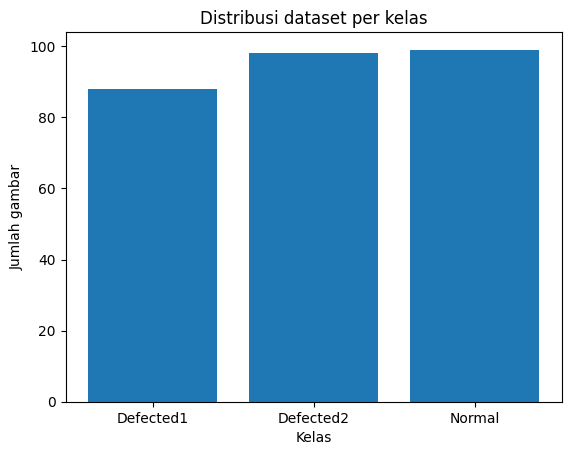

In [ ]:
import matplotlib.pyplot as plt

counts = [class_counts[i] for i in range(len(class_names))]

plt.figure()
plt.bar(class_names, counts)
plt.xlabel("Kelas")
plt.ylabel("Jumlah gambar")
plt.title("Distribusi dataset per kelas");

## 1.9 Visualsiasai Data

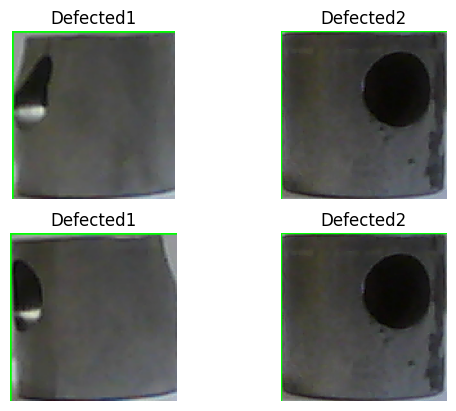

In [ ]:
import matplotlib.pyplot as plt

rows, cols = 2, 2
fig = plt.figure()
for i in range(1, rows*rows+1):
  rand_idx = torch.randint(0, len(original_dataset), size=[1]).item()
  img, label = original_dataset[rand_idx]
  fig.add_subplot(rows, cols, i)
  plt.imshow(img)
  plt.title(class_names[label])
  plt.axis(False)

# **2. Train-test Split**

In [ ]:
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset

# train test split
# ambil indeks
indecies = list(range(len(train_dataset)))

# yang di-split itu indeksnya
train_idx, test_idx = train_test_split(indecies, test_size=0.2, random_state=67, stratify=train_dataset.targets)

# buat dataset yang baru
train_data = Subset(train_dataset, train_idx)
test_data = Subset(test_dataset, test_idx)

print("Train : ", len(train_data))
print("Test : ", len(test_data))

Train :  228
Test :  57


## 2.1 DataLoader

In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_data,  batch_size=32, shuffle=False)

# **3. Load Pretrained Model, Loss Function, and Optimizer**

In [ ]:
# yang digunakan adalah efficient net
model = models.efficientnet_b0(weights="IMAGENET1K_V1").to(device)
num_classes = 3
in_features = model.classifier[1].in_features

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 60.4MB/s]


## 3.1 Arsitektur Model

In [ ]:
model

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

## 3.2. Ringkasan dari Model

In [ ]:
summary(model)

Layer (type:depth-idx)                                  Param #
EfficientNet                                            --
├─Sequential: 1-1                                       --
│    └─Conv2dNormActivation: 2-1                        --
│    │    └─Conv2d: 3-1                                 864
│    │    └─BatchNorm2d: 3-2                            64
│    │    └─SiLU: 3-3                                   --
│    └─Sequential: 2-2                                  --
│    │    └─MBConv: 3-4                                 1,448
│    └─Sequential: 2-3                                  --
│    │    └─MBConv: 3-5                                 6,004
│    │    └─MBConv: 3-6                                 10,710
│    └─Sequential: 2-4                                  --
│    │    └─MBConv: 3-7                                 15,350
│    │    └─MBConv: 3-8                                 31,290
│    └─Sequential: 2-5                                  --
│    │    └─MBConv: 3-9         

In [ ]:
for param in model.features.parameters():
  param.requires_grad = False
summary(model)

Layer (type:depth-idx)                                  Param #
EfficientNet                                            --
├─Sequential: 1-1                                       --
│    └─Conv2dNormActivation: 2-1                        --
│    │    └─Conv2d: 3-1                                 (864)
│    │    └─BatchNorm2d: 3-2                            (64)
│    │    └─SiLU: 3-3                                   --
│    └─Sequential: 2-2                                  --
│    │    └─MBConv: 3-4                                 (1,448)
│    └─Sequential: 2-3                                  --
│    │    └─MBConv: 3-5                                 (6,004)
│    │    └─MBConv: 3-6                                 (10,710)
│    └─Sequential: 2-4                                  --
│    │    └─MBConv: 3-7                                 (15,350)
│    │    └─MBConv: 3-8                                 (31,290)
│    └─Sequential: 2-5                                  --
│    │    └─MBConv

# **4. Model Training dan Test**

## 4.1 Training loop

In [ ]:
from tqdm.auto import tqdm

epoch = 3

y_train_pred  = [] # ini untuk prediksi
y_train_true = []  # ini label asli

for epoch in tqdm(range(epoch)):
  model.train()
  train_loss = 0
  for images, labels in train_loader:

    # kirim citra dan label ke device
    images, labels = images.to(device), labels.to(device)

    optimizer.zero_grad()
    outputs = model(images)          # forward pass
    loss = loss_fn(outputs, labels)  # loss function
    loss.backward()                  # back propagation
    train_loss += loss
    optimizer.step()                 # update weights and bias
    predictions = torch.argmax(torch.softmax(outputs, dim=1), dim=1)

    # update nilai prediksi dan label
    y_train_pred.extend(predictions.cpu().numpy())
    y_train_true.extend(labels.cpu().numpy())

  train_loss = train_loss / len(train_loader)            # loss dihitung manual dengan loop
  train_acc = accuracy_score(y_train_true, y_train_pred) # akurasi pakai sklearn

  print(f"Epoch: {epoch+1} | Train loss: {train_loss:.3f} | Train accuracy: {train_acc:.3f}")

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 1 | Train loss: 6.665 | Train accuracy: 0.013
Epoch: 2 | Train loss: 4.445 | Train accuracy: 0.169
Epoch: 3 | Train loss: 2.602 | Train accuracy: 0.361


## 4.2 Test loop

In [ ]:
y_test_preds = []
y_test_true  = []

model.eval()
test_loss = 0
with torch.inference_mode():

  # loop per batch
  for images, labels in test_loader:
    images, labels = images.to(device), labels.to(device)

    # keluarannya berupa logits
    test_pred_logits = model(images)

    test_loss = loss_fn(test_pred_logits, labels)
    test_pred_labels = test_pred_logits.argmax(dim=1) # [0.001, 0.0002, 0.1]

    y_test_preds.extend(test_pred_labels.cpu().numpy())
    y_test_true.extend(labels.cpu().numpy())

  test_loss = test_loss / len(test_loader)            # loss dihitung manual dengan loop
  test_acc = accuracy_score(y_test_true, y_test_preds) # akurasi pakai sklearn

  print(f"Test loss: {test_loss:.3f} | Test accuracy: {test_acc:.3f}")

Test loss: 1.709 | Test accuracy: 0.474


## 4.3 Functionalize Trainig dan Test

In [ ]:
def evaluate(model,
             train_loader,
             test_loader,
             num_classes,
             loss_fn,
             optimizer,
             epochs,
             device=device):
  """
  Fungsi evaluate digunakan untuk mengevaluasi performa dari model. Pertama, dilakukan
  training data. Kedua, dilakukan tahap evaluasi. Ketiga, dilakukan perhitungan matriks
  evaluasi.

  Return : loss train, loss test, akurasi train, akurasi test, presisi, recall, dan f1. Score

  Parameters
  -----------
  model       : model yang akan dievaluasi performanya.
  num_classes : banyak kelas dari data.
  loss_fn     : loss function.
  optimizer   : optimizer yang dipakai
  epochs      : banyak iterasi.
  device      : default = "cpu".
  """
  print("Memulai ... ")

  # untuk plot
  loss_train_hist = []
  loss_test_hist  = []
  acc_train_hist  = []
  acc_test_hist   = []

  # matriks penilaian
  precision_list = []
  recall_list = []
  f1_list = []

  print("\nTraining data ... ")
  for epoch in tqdm(range(epochs)):

    # riset prediksi dan true label setiap kali epoch
    y_train_pred  = []
    y_train_true  = []
    y_test_preds = []
    y_test_true  = []

    model.train()
    train_loss = 0
    for images, labels in train_loader:
      # kirim citra dan label ke device
      images, labels = images.to(device), labels.to(device)

      optimizer.zero_grad()
      outputs = model(images)          # forward pass
      loss = loss_fn(outputs, labels)  # loss function
      loss.backward()                  # back propagation
      train_loss += loss.item()
      optimizer.step()                 # update weights and bias
      predictions = torch.argmax(torch.softmax(outputs, dim=1), dim=1)

      # update nilai prediksi dan label
      y_train_pred.extend(predictions.cpu().numpy())
      y_train_true.extend(labels.cpu().numpy())

    train_loss = train_loss / len(train_loader)            # loss dihitung manual dengan loop
    train_acc = accuracy_score(y_train_true, y_train_pred) # akurasi pakai sklearn

    # update list yang untuk visualisasi
    loss_train_hist.append(train_loss)
    acc_train_hist.append(train_acc)

    model.eval()
    test_loss = 0
    with torch.inference_mode():
      # loop per batch
      for images, labels in test_loader:
        # kirim citra dan label ke device

        images, labels = images.to(device), labels.to(device)
        # keluarannya berupa logits
        test_pred_logits = model(images)

        loss = loss_fn(test_pred_logits, labels)
        test_loss += loss.item()
        test_pred_labels = test_pred_logits.argmax(dim=1)

        y_test_preds.extend(test_pred_labels.cpu().numpy())
        y_test_true.extend(labels.cpu().numpy())

      test_loss = test_loss / len(test_loader)            # loss dihitung manual dengan loop
      test_acc = accuracy_score(y_test_true, y_test_preds) # akurasi pakai sklearn

      # update list yang untuk visualisasi
      loss_test_hist.append(test_loss)
      acc_test_hist.append(test_acc)

      # matriks evaluasi
      precision = precision_score(y_test_true, y_test_preds, average='weighted', zero_division=0.0)
      recall    = recall_score(y_test_true, y_test_preds, average='weighted', zero_division=0.0)
      f1        = f1_score(y_test_true, y_test_preds, average='weighted')

      precision_list.append(precision)
      recall_list.append(recall)
      f1_list.append(f1)

      print(
          f"Epoch: {epoch+1} |  "
          f"Train loss: {train_loss:.3f} | "
          f"Train accuracy: {train_acc:.3f} | "
          f"Test loss: {test_loss:.3f} | "
          f"Test accuracy: {test_acc:.3f}")

  # print hasil evaluasi
  # These will use the accumulated values from the last epoch's evaluation run
  final_test_acc = accuracy_score(y_test_true, y_test_preds)
  final_precision = precision_score(y_test_true, y_test_preds, average='weighted', zero_division=0.0)
  final_recall    = recall_score(y_test_true, y_test_preds, average='weighted', zero_division=0.0)
  final_f1        = f1_score(y_test_true, y_test_preds, average='weighted')
  final_test_loss = test_loss # This will be the last epoch's test loss

  print(f"\n--- Hasil Evaluasi Model ---")
  print(f"Accuracy  : {final_test_acc*100:.2f}%")
  print(f"Precision : {final_precision*100:.2f}%")
  print(f"Recall    : {final_recall*100:.2f}%")
  print(f"F1-Score  : {final_f1*100:.2f}%")
  print(f"Loss      : {final_test_loss:.2f}")

  return (loss_train_hist, loss_test_hist, acc_train_hist, acc_test_hist, precision_list, recall_list, f1_list)

## 4.4 Training Model Awal (`model_0`)

In [ ]:
model_0 = models.efficientnet_b0(weights="IMAGENET1K_V1").to(device)
num_classes = 3
epochs = 25 # Updated epochs to match the function call

for param in model_0.features.parameters():
  param.requires_grad = False
model_0.classifier = nn.Sequential(
    nn.Dropout(p=0.2, inplace=True),
    nn.Linear(in_features=1280, out_features=len(class_names)).to(device))

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_0.parameters(), lr=0.0001)

loss_train, loss_test, acc_train, acc_test, precision_list, recall_list, f1_list = evaluate(
             model=model_0,
             train_loader=train_loader,
             test_loader=test_loader,
             num_classes=num_classes,
             loss_fn=loss_fn,
             optimizer=optimizer,
             epochs=epochs,
             device=device)

Memulai ... 

Training data ... 


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch: 1 |  Train loss: 1.096 | Train accuracy: 0.360 | Test loss: 1.083 | Test accuracy: 0.368
Epoch: 2 |  Train loss: 1.093 | Train accuracy: 0.434 | Test loss: 1.068 | Test accuracy: 0.474
Epoch: 3 |  Train loss: 1.036 | Train accuracy: 0.469 | Test loss: 1.037 | Test accuracy: 0.526
Epoch: 4 |  Train loss: 1.015 | Train accuracy: 0.592 | Test loss: 1.005 | Test accuracy: 0.667
Epoch: 5 |  Train loss: 0.989 | Train accuracy: 0.640 | Test loss: 0.973 | Test accuracy: 0.719
Epoch: 6 |  Train loss: 0.974 | Train accuracy: 0.658 | Test loss: 0.948 | Test accuracy: 0.737
Epoch: 7 |  Train loss: 0.938 | Train accuracy: 0.711 | Test loss: 0.928 | Test accuracy: 0.789
Epoch: 8 |  Train loss: 0.918 | Train accuracy: 0.732 | Test loss: 0.898 | Test accuracy: 0.842
Epoch: 9 |  Train loss: 0.876 | Train accuracy: 0.794 | Test loss: 0.883 | Test accuracy: 0.807
Epoch: 10 |  Train loss: 0.880 | Train accuracy: 0.781 | Test loss: 0.858 | Test accuracy: 0.842
Epoch: 11 |  Train loss: 0.859 | Train 

## 4.5 Visualisasi Loss dan Akurasi

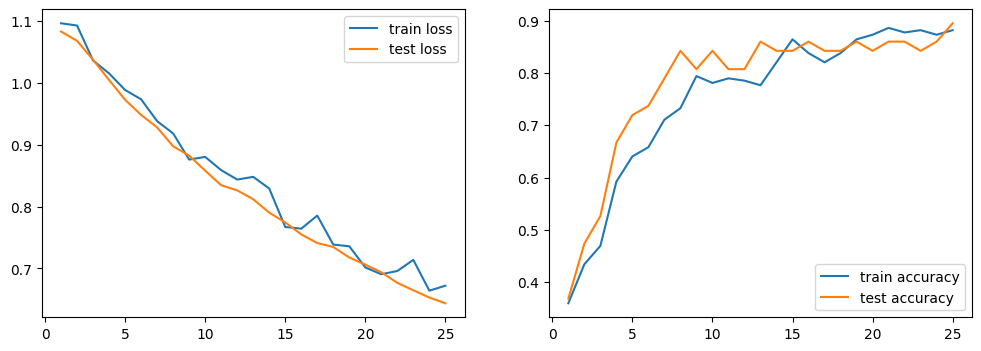

In [ ]:
t = list(range(1, epochs+1))
epochs = 20

plt.figure(figsize=(12, 4))
plt.subplot(121)
plt.plot(t, loss_train, label="train loss")
plt.plot(t, loss_test, label="test loss")
plt.legend()

plt.subplot(122)
plt.plot(t, acc_train, label="train accuracy")
plt.plot(t, acc_test, label="test accuracy")
plt.legend();

# **5. Cross-validation**

## 5.1 Freeze Backbone (`model_1`)

In [ ]:
from sklearn.model_selection import KFold

splits = 5
kfold = KFold(n_splits=splits, shuffle=True, random_state=67) # random state untuk reproduksibilitas

# menggunakan original_dataset (tanpa transformasi) untuk mendapatkan indeks untuk splitting
# untuk memastikan indeks konsisten untuk semua folds, tanpa peduli transfomasi tertentu
all_indices = list(range(len(original_dataset)))
all_targets = original_dataset.targets

# matriks evaluasi per fold
precision_scores = []
accuracy_scores = []
loss_scores = []
recall_scores = []
f1_scores = []

for fold, (train_indices, test_indices) in enumerate(kfold.split(all_indices, all_targets)):
  print(f"--- Fold {fold+1}/{splits} ---")

  # buat train dan test data untuk fold yang sekarang, dan menlakukan transformasi yang sesuai
  fold_train_data = Subset(train_dataset, train_indices)
  fold_test_data  = Subset(test_dataset, test_indices)

  # membuat loaders untuk fold yang sekarang
  train_loader_fold = DataLoader(fold_train_data, batch_size=32, shuffle=True)
  test_loader_fold  = DataLoader(fold_test_data,  batch_size=32, shuffle=False)

  # inisiasi model, loss function dan optimizer untuk setiap fold
  # ini memastikan bobot model di-riset untuk setiap fold (standar evaluasi K-Fold)
  model_1 = models.efficientnet_b0(weights="IMAGENET1K_V1").to(device)

  # freeze parameters dan modifikasi classifier untuk model baru setiap kali fold
  for param in model_1.features.parameters():
    param.requires_grad = False
  model_1.classifier = nn.Sequential(
      nn.Dropout(p=0.2, inplace=True),
      nn.Linear(in_features=1280, out_features=len(class_names)).to(device)
  )

  num_classes = 3
  loss_fn = nn.CrossEntropyLoss()
  optimizer = torch.optim.Adam(model_1.parameters(), lr=0.0001)
  epochs = 25 # bisa disesuaikan

  # menggunakan evaluate() function untuk fold yang sekarang
  loss_train_hist, loss_test_hist, acc_train_hist, acc_test_hist, precision_list, recall_list, f1_list = evaluate(
             model=model_1,
             train_loader=train_loader_fold,
             test_loader=test_loader_fold,
             num_classes=num_classes,
             loss_fn=loss_fn,
             optimizer=optimizer,
             epochs=epochs,
             device=device)

  # tambahkan matriks final untuk fold ini
  # evaluate() memberikan matriks per epoch, jadi yang kita ambil ada elemen terakhir
  precision_scores.append(precision_list[-1])
  accuracy_scores.append(acc_test_hist[-1])
  loss_scores.append(loss_test_hist[-1])
  recall_scores.append(recall_list[-1])
  f1_scores.append(f1_list[-1])

print("\n--- Overall K-Fold Results ---")
if splits > 0:
    print(f"Average Accuracy  : {sum(accuracy_scores)/len(accuracy_scores)*100:.2f}%")
    print(f"Average Precision : {sum(precision_scores)/len(precision_scores)*100:.2f}%")
    print(f"Average Recall    : {sum(recall_scores)/len(recall_scores)*100:.2f}%")
    print(f"Average F1-Score  : {sum(f1_scores)/len(f1_scores)*100:.2f}%")
    print(f"Average Loss      : {sum(loss_scores)/len(loss_scores):.3f}")
else:
    print("No folds processed.")

--- Fold 1/5 ---
Memulai ... 

Training data ... 


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch: 1 |  Train loss: 1.087 | Train accuracy: 0.346 | Test loss: 1.129 | Test accuracy: 0.421
Epoch: 2 |  Train loss: 1.071 | Train accuracy: 0.430 | Test loss: 1.094 | Test accuracy: 0.509
Epoch: 3 |  Train loss: 1.048 | Train accuracy: 0.539 | Test loss: 1.056 | Test accuracy: 0.632
Epoch: 4 |  Train loss: 1.015 | Train accuracy: 0.561 | Test loss: 1.029 | Test accuracy: 0.632
Epoch: 5 |  Train loss: 0.986 | Train accuracy: 0.588 | Test loss: 1.008 | Test accuracy: 0.614
Epoch: 6 |  Train loss: 0.955 | Train accuracy: 0.702 | Test loss: 0.990 | Test accuracy: 0.667
Epoch: 7 |  Train loss: 0.928 | Train accuracy: 0.754 | Test loss: 0.964 | Test accuracy: 0.702
Epoch: 8 |  Train loss: 0.896 | Train accuracy: 0.772 | Test loss: 0.943 | Test accuracy: 0.702
Epoch: 9 |  Train loss: 0.901 | Train accuracy: 0.759 | Test loss: 0.921 | Test accuracy: 0.702
Epoch: 10 |  Train loss: 0.866 | Train accuracy: 0.776 | Test loss: 0.896 | Test accuracy: 0.719
Epoch: 11 |  Train loss: 0.846 | Train 

  0%|          | 0/25 [00:00<?, ?it/s]

Epoch: 1 |  Train loss: 1.115 | Train accuracy: 0.303 | Test loss: 1.100 | Test accuracy: 0.263
Epoch: 2 |  Train loss: 1.068 | Train accuracy: 0.425 | Test loss: 1.079 | Test accuracy: 0.386
Epoch: 3 |  Train loss: 1.038 | Train accuracy: 0.456 | Test loss: 1.046 | Test accuracy: 0.526
Epoch: 4 |  Train loss: 1.021 | Train accuracy: 0.509 | Test loss: 1.018 | Test accuracy: 0.614
Epoch: 5 |  Train loss: 0.989 | Train accuracy: 0.601 | Test loss: 1.004 | Test accuracy: 0.614
Epoch: 6 |  Train loss: 0.957 | Train accuracy: 0.632 | Test loss: 0.983 | Test accuracy: 0.667
Epoch: 7 |  Train loss: 0.936 | Train accuracy: 0.719 | Test loss: 0.967 | Test accuracy: 0.719
Epoch: 8 |  Train loss: 0.910 | Train accuracy: 0.759 | Test loss: 0.952 | Test accuracy: 0.789
Epoch: 9 |  Train loss: 0.910 | Train accuracy: 0.785 | Test loss: 0.934 | Test accuracy: 0.789
Epoch: 10 |  Train loss: 0.881 | Train accuracy: 0.842 | Test loss: 0.919 | Test accuracy: 0.825
Epoch: 11 |  Train loss: 0.838 | Train 

...

Epoch: 1 |  Train loss: 1.111 | Train accuracy: 0.346 | Test loss: 1.140 | Test accuracy: 0.211
Epoch: 2 |  Train loss: 1.070 | Train accuracy: 0.417 | Test loss: 1.092 | Test accuracy: 0.368
Epoch: 3 |  Train loss: 1.054 | Train accuracy: 0.522 | Test loss: 1.053 | Test accuracy: 0.509
Epoch: 4 |  Train loss: 1.007 | Train accuracy: 0.553 | Test loss: 1.025 | Test accuracy: 0.632
Epoch: 5 |  Train loss: 0.996 | Train accuracy: 0.610 | Test loss: 0.989 | Test accuracy: 0.737
Epoch: 6 |  Train loss: 0.967 | Train accuracy: 0.658 | Test loss: 0.967 | Test accuracy: 0.754
Epoch: 7 |  Train loss: 0.958 | Train accuracy: 0.715 | Test loss: 0.940 | Test accuracy: 0.877
Epoch: 8 |  Train loss: 0.922 | Train accuracy: 0.728 | Test loss: 0.914 | Test accuracy: 0.877
Epoch: 9 |  Train loss: 0.898 | Train accuracy: 0.772 | Test loss: 0.896 | Test accuracy: 0.912
Epoch: 10 |  Train loss: 0.890 | Train accuracy: 0.768 | Test loss: 0.877 | Test accuracy: 0.912
Epoch: 11 |  Train loss: 0.874 | Train 

  0%|          | 0/25 [00:00<?, ?it/s]

Epoch: 1 |  Train loss: 1.144 | Train accuracy: 0.285 | Test loss: 1.134 | Test accuracy: 0.211
Epoch: 2 |  Train loss: 1.089 | Train accuracy: 0.417 | Test loss: 1.065 | Test accuracy: 0.421
Epoch: 3 |  Train loss: 1.038 | Train accuracy: 0.443 | Test loss: 1.025 | Test accuracy: 0.579
Epoch: 4 |  Train loss: 1.009 | Train accuracy: 0.535 | Test loss: 0.994 | Test accuracy: 0.702
Epoch: 5 |  Train loss: 1.006 | Train accuracy: 0.588 | Test loss: 0.967 | Test accuracy: 0.789
Epoch: 6 |  Train loss: 0.971 | Train accuracy: 0.684 | Test loss: 0.939 | Test accuracy: 0.825
Epoch: 7 |  Train loss: 0.948 | Train accuracy: 0.658 | Test loss: 0.914 | Test accuracy: 0.807
Epoch: 8 |  Train loss: 0.928 | Train accuracy: 0.719 | Test loss: 0.890 | Test accuracy: 0.825
Epoch: 9 |  Train loss: 0.922 | Train accuracy: 0.776 | Test loss: 0.873 | Test accuracy: 0.807
Epoch: 10 |  Train loss: 0.890 | Train accuracy: 0.759 | Test loss: 0.854 | Test accuracy: 0.842
Epoch: 11 |  Train loss: 0.853 | Train 

  0%|          | 0/25 [00:00<?, ?it/s]

Epoch: 1 |  Train loss: 1.080 | Train accuracy: 0.399 | Test loss: 1.122 | Test accuracy: 0.281
Epoch: 2 |  Train loss: 1.060 | Train accuracy: 0.443 | Test loss: 1.102 | Test accuracy: 0.316
Epoch: 3 |  Train loss: 1.037 | Train accuracy: 0.504 | Test loss: 1.083 | Test accuracy: 0.351
Epoch: 4 |  Train loss: 1.008 | Train accuracy: 0.601 | Test loss: 1.053 | Test accuracy: 0.368
Epoch: 5 |  Train loss: 0.984 | Train accuracy: 0.605 | Test loss: 1.013 | Test accuracy: 0.526
Epoch: 6 |  Train loss: 0.994 | Train accuracy: 0.623 | Test loss: 0.998 | Test accuracy: 0.561
Epoch: 7 |  Train loss: 0.962 | Train accuracy: 0.658 | Test loss: 0.949 | Test accuracy: 0.684
Epoch: 8 |  Train loss: 0.934 | Train accuracy: 0.732 | Test loss: 0.924 | Test accuracy: 0.737
Epoch: 9 |  Train loss: 0.878 | Train accuracy: 0.763 | Test loss: 0.909 | Test accuracy: 0.737
Epoch: 10 |  Train loss: 0.877 | Train accuracy: 0.785 | Test loss: 0.900 | Test accuracy: 0.737
Epoch: 11 |  Train loss: 0.834 | Train 

## 5.2 Full Trainable Prameters (`model_2`)

In [ ]:
from sklearn.model_selection import KFold

splits = 5
kfold = KFold(n_splits=splits, shuffle=True, random_state=67) # random state untuk reproduksibilitas

# menggunakan original_dataset (tanpa transformasi) untuk mendapatkan indeks untuk splitting
# untuk memastikan indeks konsisten untuk semua folds, tanpa peduli transfomasi tertentu
all_indices = list(range(len(original_dataset)))
all_targets = original_dataset.targets

# matriks evaluasi per fold
precision_scores = []
accuracy_scores = []
loss_scores = []
recall_scores = []
f1_scores = []

for fold, (train_indices, test_indices) in enumerate(kfold.split(all_indices, all_targets)):
  print(f"--- Fold {fold+1}/{splits} ---")

  # buat train dan test data untuk fold yang sekarang, dan menlakukan transformasi yang sesuai
  fold_train_data = Subset(train_dataset, train_indices)
  fold_test_data  = Subset(test_dataset, test_indices)

  # membuat loaders untuk fold yang sekarang
  train_loader_fold = DataLoader(fold_train_data, batch_size=32, shuffle=True)
  test_loader_fold  = DataLoader(fold_test_data,  batch_size=32, shuffle=False)

  # inisiasi model, loss function dan optimizer untuk setiap fold
  # ini memastikan bobot model di-riset untuk setiap fold (standar evaluasi K-Fold)
  model_2 = models.efficientnet_b0(weights="IMAGENET1K_V1").to(device)

  # unfreeze parameters dan modifikasi classifier untuk model baru setiap kali fold
  # for param in model_1.features.parameters():
  #   param.requires_grad = False
  model_2.classifier = nn.Sequential(
      nn.Dropout(p=0.2, inplace=True),
      nn.Linear(in_features=1280, out_features=len(class_names)).to(device)
  )

  num_classes = 3
  loss_fn = nn.CrossEntropyLoss()
  optimizer = torch.optim.Adam(model_2.parameters(), lr=0.0001)
  epochs = 25 # bisa disesuaikan

  # menggunakan evaluate() function untuk fold yang sekarang
  loss_train_hist, loss_test_hist, acc_train_hist, acc_test_hist, precision_list, recall_list, f1_list = evaluate(
             model=model_2,
             train_loader=train_loader_fold,
             test_loader=test_loader_fold,
             num_classes=num_classes,
             loss_fn=loss_fn,
             optimizer=optimizer,
             epochs=epochs,
             device=device)

  # tambahkan matriks final untuk fold ini
  # evaluate() memberikan matriks per epoch, jadi yang kita ambil ada elemen terakhir
  precision_scores.append(precision_list[-1])
  accuracy_scores.append(acc_test_hist[-1])
  loss_scores.append(loss_test_hist[-1])
  recall_scores.append(recall_list[-1])
  f1_scores.append(f1_list[-1])

print("\n--- Overall K-Fold Results ---")
if splits > 0:
    print(f"Average Accuracy  : {sum(accuracy_scores)/len(accuracy_scores)*100:.2f}%")
    print(f"Average Precision : {sum(precision_scores)/len(precision_scores)*100:.2f}%")
    print(f"Average Recall    : {sum(recall_scores)/len(recall_scores)*100:.2f}%")
    print(f"Average F1-Score  : {sum(f1_scores)/len(f1_scores)*100:.2f}%")
    print(f"Average Loss      : {sum(loss_scores)/len(loss_scores):.3f}")
else:
    print("No folds processed.")

--- Fold 1/5 ---
Memulai ... 

Training data ... 


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch: 1 |  Train loss: 0.984 | Train accuracy: 0.623 | Test loss: 1.016 | Test accuracy: 0.737
Epoch: 2 |  Train loss: 0.661 | Train accuracy: 0.908 | Test loss: 0.815 | Test accuracy: 0.912
Epoch: 3 |  Train loss: 0.462 | Train accuracy: 0.930 | Test loss: 0.534 | Test accuracy: 0.947
Epoch: 4 |  Train loss: 0.319 | Train accuracy: 0.965 | Test loss: 0.327 | Test accuracy: 0.947
Epoch: 5 |  Train loss: 0.326 | Train accuracy: 0.961 | Test loss: 0.201 | Test accuracy: 0.982
Epoch: 6 |  Train loss: 0.153 | Train accuracy: 0.991 | Test loss: 0.125 | Test accuracy: 1.000
Epoch: 7 |  Train loss: 0.104 | Train accuracy: 0.996 | Test loss: 0.085 | Test accuracy: 1.000
Epoch: 8 |  Train loss: 0.088 | Train accuracy: 0.991 | Test loss: 0.062 | Test accuracy: 1.000
Epoch: 9 |  Train loss: 0.054 | Train accuracy: 1.000 | Test loss: 0.027 | Test accuracy: 1.000
Epoch: 10 |  Train loss: 0.037 | Train accuracy: 1.000 | Test loss: 0.017 | Test accuracy: 1.000
Epoch: 11 |  Train loss: 0.084 | Train 

  0%|          | 0/25 [00:00<?, ?it/s]

Epoch: 1 |  Train loss: 0.965 | Train accuracy: 0.592 | Test loss: 1.000 | Test accuracy: 0.456
Epoch: 2 |  Train loss: 0.728 | Train accuracy: 0.873 | Test loss: 0.842 | Test accuracy: 0.772
Epoch: 3 |  Train loss: 0.517 | Train accuracy: 0.899 | Test loss: 0.606 | Test accuracy: 0.772
Epoch: 4 |  Train loss: 0.306 | Train accuracy: 0.969 | Test loss: 0.372 | Test accuracy: 0.930
Epoch: 5 |  Train loss: 0.228 | Train accuracy: 0.987 | Test loss: 0.237 | Test accuracy: 1.000
Epoch: 6 |  Train loss: 0.144 | Train accuracy: 0.991 | Test loss: 0.118 | Test accuracy: 1.000
Epoch: 7 |  Train loss: 0.088 | Train accuracy: 1.000 | Test loss: 0.079 | Test accuracy: 1.000
Epoch: 8 |  Train loss: 0.079 | Train accuracy: 0.991 | Test loss: 0.067 | Test accuracy: 1.000
Epoch: 9 |  Train loss: 0.085 | Train accuracy: 0.996 | Test loss: 0.047 | Test accuracy: 1.000
Epoch: 10 |  Train loss: 0.048 | Train accuracy: 1.000 | Test loss: 0.029 | Test accuracy: 1.000
Epoch: 11 |  Train loss: 0.130 | Train 

...

Epoch: 1 |  Train loss: 0.994 | Train accuracy: 0.605 | Test loss: 1.045 | Test accuracy: 0.368
Epoch: 2 |  Train loss: 0.680 | Train accuracy: 0.925 | Test loss: 0.803 | Test accuracy: 0.895
Epoch: 3 |  Train loss: 0.487 | Train accuracy: 0.947 | Test loss: 0.485 | Test accuracy: 0.965
Epoch: 4 |  Train loss: 0.354 | Train accuracy: 0.965 | Test loss: 0.260 | Test accuracy: 0.965
Epoch: 5 |  Train loss: 0.326 | Train accuracy: 0.965 | Test loss: 0.136 | Test accuracy: 0.982
Epoch: 6 |  Train loss: 0.150 | Train accuracy: 0.991 | Test loss: 0.083 | Test accuracy: 1.000
Epoch: 7 |  Train loss: 0.101 | Train accuracy: 0.991 | Test loss: 0.058 | Test accuracy: 1.000
Epoch: 8 |  Train loss: 0.102 | Train accuracy: 0.996 | Test loss: 0.048 | Test accuracy: 0.982
Epoch: 9 |  Train loss: 0.113 | Train accuracy: 0.996 | Test loss: 0.024 | Test accuracy: 1.000
Epoch: 10 |  Train loss: 0.045 | Train accuracy: 1.000 | Test loss: 0.022 | Test accuracy: 1.000
Epoch: 11 |  Train loss: 0.037 | Train 

  0%|          | 0/25 [00:00<?, ?it/s]

Epoch: 1 |  Train loss: 0.915 | Train accuracy: 0.693 | Test loss: 1.049 | Test accuracy: 0.421
Epoch: 2 |  Train loss: 0.607 | Train accuracy: 0.890 | Test loss: 0.784 | Test accuracy: 0.789
Epoch: 3 |  Train loss: 0.465 | Train accuracy: 0.912 | Test loss: 0.384 | Test accuracy: 0.982
Epoch: 4 |  Train loss: 0.362 | Train accuracy: 0.974 | Test loss: 0.193 | Test accuracy: 0.982
Epoch: 5 |  Train loss: 0.172 | Train accuracy: 0.987 | Test loss: 0.098 | Test accuracy: 1.000
Epoch: 6 |  Train loss: 0.123 | Train accuracy: 0.991 | Test loss: 0.052 | Test accuracy: 1.000
Epoch: 7 |  Train loss: 0.083 | Train accuracy: 0.996 | Test loss: 0.036 | Test accuracy: 1.000
Epoch: 8 |  Train loss: 0.086 | Train accuracy: 0.996 | Test loss: 0.022 | Test accuracy: 1.000
Epoch: 9 |  Train loss: 0.059 | Train accuracy: 0.991 | Test loss: 0.018 | Test accuracy: 1.000
Epoch: 10 |  Train loss: 0.064 | Train accuracy: 0.991 | Test loss: 0.021 | Test accuracy: 1.000
Epoch: 11 |  Train loss: 0.070 | Train 

  0%|          | 0/25 [00:00<?, ?it/s]

Epoch: 1 |  Train loss: 0.988 | Train accuracy: 0.614 | Test loss: 1.042 | Test accuracy: 0.316
Epoch: 2 |  Train loss: 0.685 | Train accuracy: 0.904 | Test loss: 0.847 | Test accuracy: 0.772
Epoch: 3 |  Train loss: 0.468 | Train accuracy: 0.961 | Test loss: 0.513 | Test accuracy: 0.947
Epoch: 4 |  Train loss: 0.302 | Train accuracy: 0.965 | Test loss: 0.311 | Test accuracy: 0.947
Epoch: 5 |  Train loss: 0.206 | Train accuracy: 0.974 | Test loss: 0.199 | Test accuracy: 0.947
Epoch: 6 |  Train loss: 0.238 | Train accuracy: 0.978 | Test loss: 0.122 | Test accuracy: 0.947
Epoch: 7 |  Train loss: 0.150 | Train accuracy: 0.991 | Test loss: 0.074 | Test accuracy: 0.982
Epoch: 8 |  Train loss: 0.095 | Train accuracy: 0.996 | Test loss: 0.061 | Test accuracy: 1.000
Epoch: 9 |  Train loss: 0.066 | Train accuracy: 1.000 | Test loss: 0.041 | Test accuracy: 1.000
Epoch: 10 |  Train loss: 0.078 | Train accuracy: 0.996 | Test loss: 0.024 | Test accuracy: 1.000
Epoch: 11 |  Train loss: 0.084 | Train 

# **6. Final Results**

## 6.1 Results




Matrix | Paper |  `model_1` | `model_2`
--| -- | -- | --
Loss | 0.156 |  0.663 | 0.000
Accuracy | 0.689 | 0.954 | 1.000
Recall | 0.690 | 0.954 | 1.000
Precision | 0.700 | 0.959 | 1.000
f1 score | - | 0.954 | 1.000


## 6.2 Confusion Matrix

In [ ]:
y_pred = []
y_test = []

model_1.eval()
with torch.inference_mode():
  # loop per batch
  for images, labels in test_loader:

    # kirim ke device
    images, labels = images.to(device), labels.to(device)
    # keluarannya berupa logits
    test_pred_logits = model_1(images)

    test_loss = loss_fn(test_pred_logits, labels)
    test_pred_labels = test_pred_logits.argmax(dim=1)

    y_pred.extend(test_pred_labels)
    y_test.extend(labels)

y_test = [i.cpu().numpy() for i in y_test]
y_pred = [i.cpu().numpy() for i in y_pred]

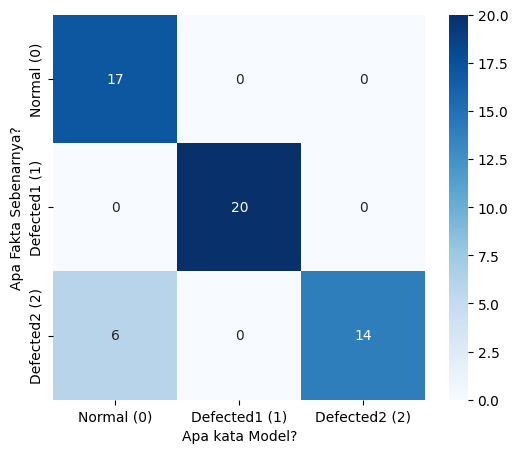

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Buat Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Plotting
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal (0)', 'Defected1 (1)', 'Defected2 (2)'],
            yticklabels=['Normal (0)', 'Defected1 (1)', 'Defected2 (2)'])

plt.xlabel('Apa kata Model?')
plt.ylabel('Apa Fakta Sebenarnya?')
plt.show()

# **7. Predictions**

In [ ]:
def denormalize(tensor):
    # Mean dan STD yang Anda gunakan tadi
    mean = torch.tensor([0.485, 0.456, 0.406])
    std = torch.tensor([0.229, 0.224, 0.225])

    # Clone tensor agar tidak mengubah data asli
    t = tensor.clone()

    # Jika tensor memiliki batch dimension [B, C, H, W], ambil index 0 atau sesuaikan
    # Rumus: t * std + mean
    # Kita perlu mengubah bentuk mean/std agar bisa dikalikan dengan tensor (C, H, W)
    for t_chan, m, s in zip(t, mean, std):
        t_chan.mul_(s).add_(m)

    return t

/tmp/ipython-input-3058652912.py:8: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(3,3))


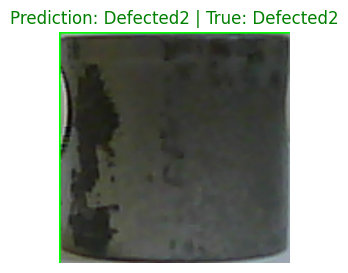

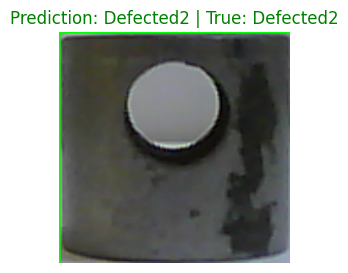

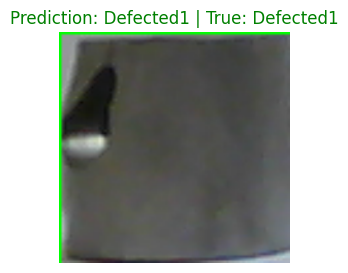

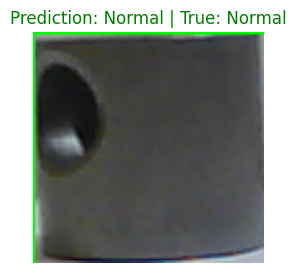

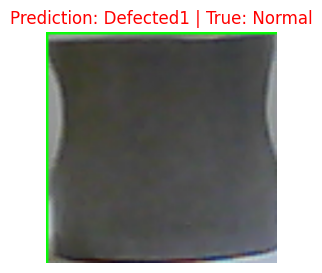

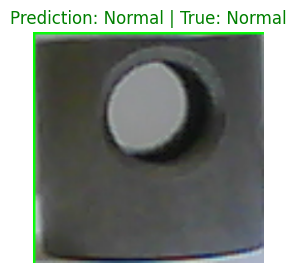

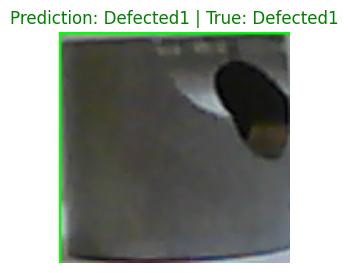

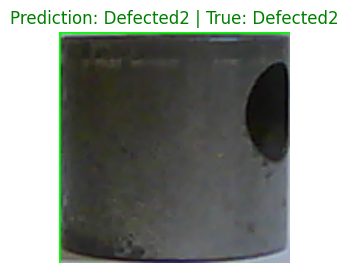

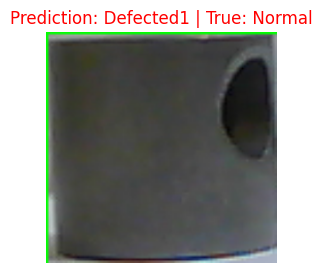

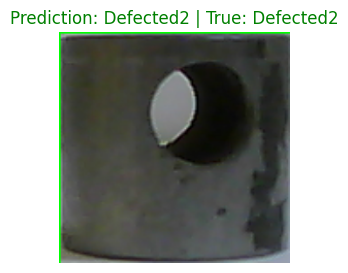

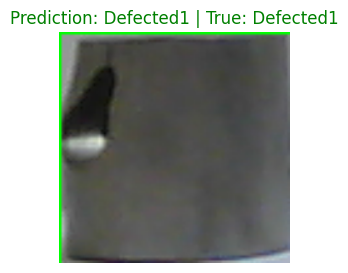

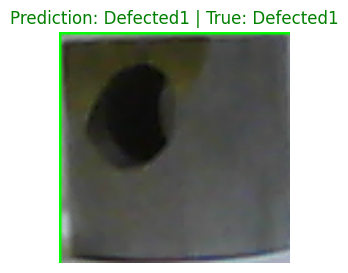

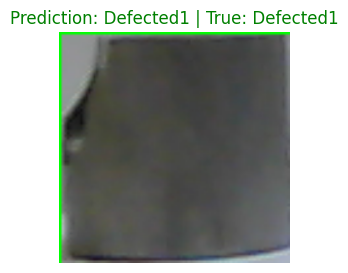

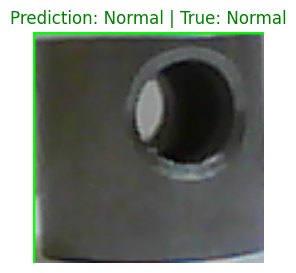

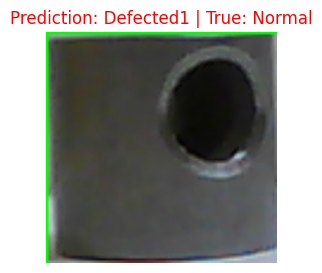

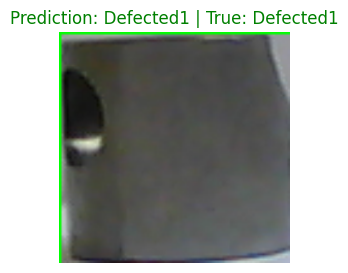

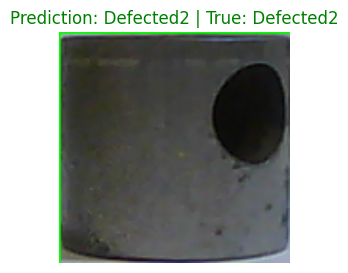

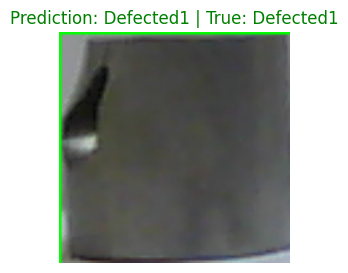

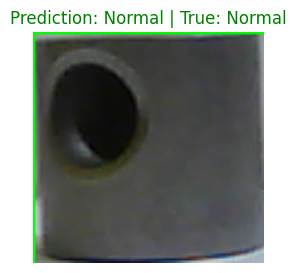

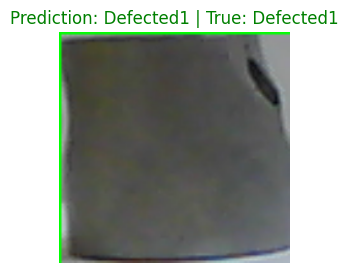

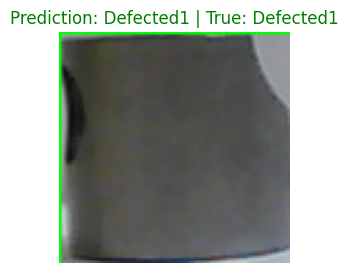

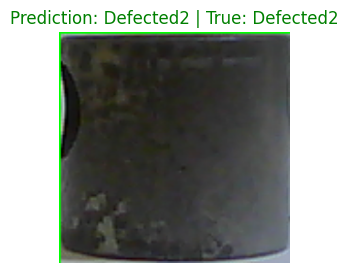

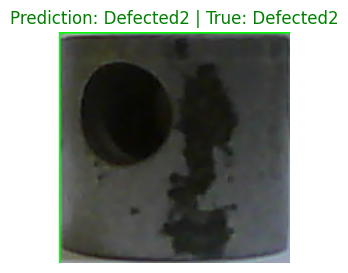

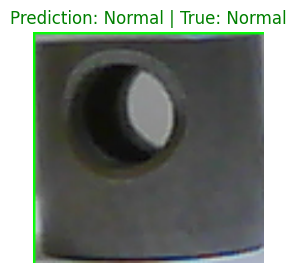

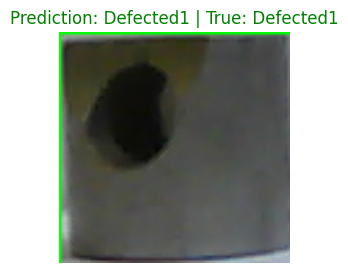

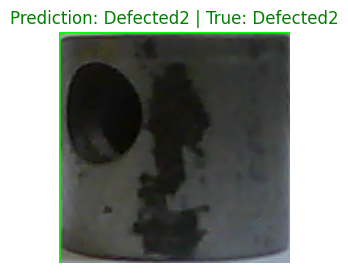

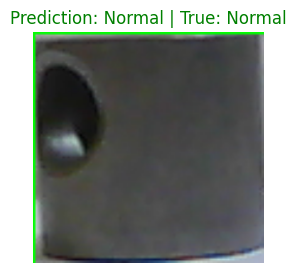

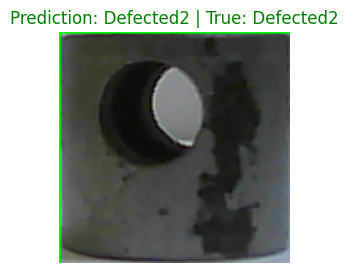

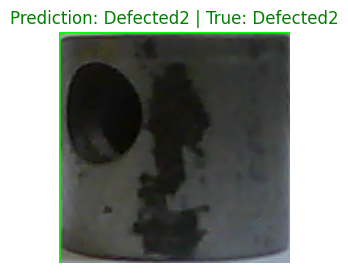

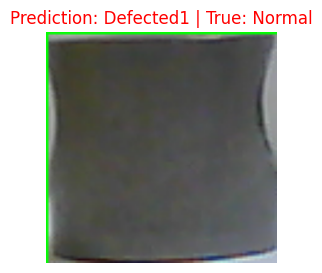

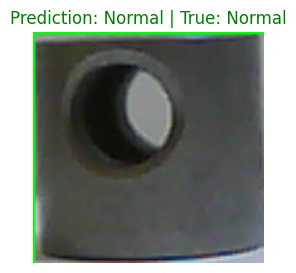

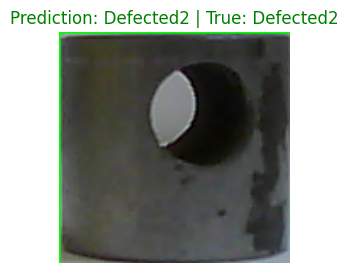

In [ ]:
images, labels = next(iter(test_loader))

for index, image in enumerate(images):
  image = denormalize(image)
  title_true = class_names[y_test[index]]
  title_pred = class_names[y_pred[index]]
  title_text = f"Prediction: {title_pred} | True: {title_true}"
  plt.figure(figsize=(3,3))
  plt.imshow(image.permute(1, 2, 0))
  if title_true == title_pred:
    plt.title(title_text, c="g")
  else:
    plt.title(title_text, c="red")
  plt.axis("off")

# **8. Conclusion**

Kesimpulan:

1. Metode transfer learning sangat efektif digunakan dalam klasifikasi. Ini dibuktikan dengan model yang dapat mencapai akurasi tinggi walaupun dengan jumlah data yang sedikit (285 data).
2. Pada model fitur extrator, model cepat secara komputasi. Pada model fine-tuning, model memperoleh akurasi sempurna, tetapi beresiko overfitting.
3. Akurasi 100% yang diperoleh model fine-tuning kemungkinan besar berasal dari dataset citra yang terkontrol dan sedikit.
4. KFold digunakan untuk menguji robustness dari model. Rata-rata akurasi model adalah 95,4% dan 100% untuk model feature extractor dan fine tuning. Ini berarti model tidak sekadar beruntung, tetapi memang stabil untuk pembagian dataset dengan kfold 5 splits.